# Final Model Walkthrough

This notebook presents the final submission model for the Scrabble Player Rating project.

It uses:

- metadata features from `train.csv`, `test.csv`, and `games.csv`
- turn-level aggregate features derived from `turns.csv`

The selected final model is `blend_ridge_hist`, a weighted ensemble of a tuned ridge regression pipeline and a tuned histogram gradient boosting pipeline.


In [1]:
import sys
from pathlib import Path
import warnings

ROOT = Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

from src.baseline_model import build_folded_train_frame, evaluate_models, load_test_frame
from src.model_candidates import (
    WeightedBlendRegressor,
    evaluate_candidates,
    fit_best_candidate_model,
    get_candidate_builders,
    infer_feature_lists,
    load_turn_feature_table,
    merge_optional_features,
    predict_test_frame,
)

warnings.filterwarnings("ignore", message="X does not have valid feature names")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load Training, Test, and Turn-Level Feature Tables

In [2]:
train_frame = build_folded_train_frame(n_splits=5, seed=42)
test_frame = load_test_frame()
turn_feature_frame = load_turn_feature_table()

combined_train = merge_optional_features(
    train_frame,
    turn_feature_frame,
    key_columns=["game_id", "human_nickname"],
)

summary = pd.DataFrame(
    [
        {"table": "train_frame", "rows": len(train_frame), "columns": train_frame.shape[1]},
        {"table": "test_frame", "rows": len(test_frame), "columns": test_frame.shape[1]},
        {"table": "turn_feature_frame", "rows": len(turn_feature_frame), "columns": turn_feature_frame.shape[1]},
        {"table": "combined_train", "rows": len(combined_train), "columns": combined_train.shape[1]},
    ]
)
summary

,table,rows,columns
0,train_frame,50410,22
1,test_frame,22363,20
2,turn_feature_frame,145546,34
3,combined_train,50410,54


## 2. Metadata-Only Baseline

In [3]:
baseline_results = evaluate_models(train_frame, n_splits=5)
baseline_summary = pd.DataFrame(
    [
        {"model": item["model"], "avg_rmse": item["avg_rmse"], "avg_mae": item["avg_mae"]}
        for item in baseline_results
    ]
).sort_values("avg_rmse").reset_index(drop=True)

baseline_summary

,model,avg_rmse,avg_mae
0,ridge_onehot,147.231708,112.061409
1,hist_gbm,157.077253,122.712789
2,global_mean,238.827207,208.140681


## 3. Final Candidate Comparison On Metadata + Turn Features

In [4]:
candidate_summary = evaluate_candidates(
    train_frame,
    feature_frame=turn_feature_frame,
    key_columns=["game_id", "human_nickname"],
)

candidate_summary

,model,avg_rmse,avg_mae,std_rmse,std_mae,num_numeric_features,num_categorical_features
0,blend_ridge_hist,141.935523,109.676954,18.416445,18.572429,43,7
1,ridge_onehot,145.115038,111.499245,17.499192,18.097445,43,7
2,xgboost,151.254852,120.618793,14.430689,11.234748,43,7
3,hist_gbm,153.147304,119.649281,18.746610,16.619533,43,7
4,lightgbm,153.714586,119.348287,19.495727,16.574053,43,7


In [5]:
def evaluate_candidates_verbose(train_frame, feature_frame):
    merged = merge_optional_features(
        train_frame,
        feature_frame,
        key_columns=["game_id", "human_nickname"],
    )
    numeric_features, categorical_features = infer_feature_lists(
        merged,
        target_column="human_rating",
        exclude_columns=["game_id", "human_nickname"],
    )
    rows = []
    builders = get_candidate_builders()

    for model_name, builder in builders.items():
        for fold in sorted(merged["fold"].unique()):
            train_fold = merged[merged["fold"] != fold]
            valid_fold = merged[merged["fold"] == fold]

            x_train = train_fold[numeric_features + categorical_features]
            y_train = train_fold["human_rating"]
            x_valid = valid_fold[numeric_features + categorical_features]
            y_valid = valid_fold["human_rating"]

            model = builder(numeric_features, categorical_features)
            model.fit(x_train, y_train)
            preds = model.predict(x_valid)

            rows.append(
                {
                    "model": model_name,
                    "fold": int(fold),
                    "rmse": float(root_mean_squared_error(y_valid, preds)),
                    "mae": float(mean_absolute_error(y_valid, preds)),
                }
            )

    return pd.DataFrame(rows)


candidate_folds = evaluate_candidates_verbose(train_frame, turn_feature_frame)
candidate_folds.head()

,model,fold,rmse,mae
0,ridge_onehot,0,111.157307,76.614222
1,ridge_onehot,1,159.988007,127.741869
2,ridge_onehot,2,152.518656,112.880347
3,ridge_onehot,3,146.848434,118.409969
4,ridge_onehot,4,155.062786,121.849817


## 4. Visual Comparison

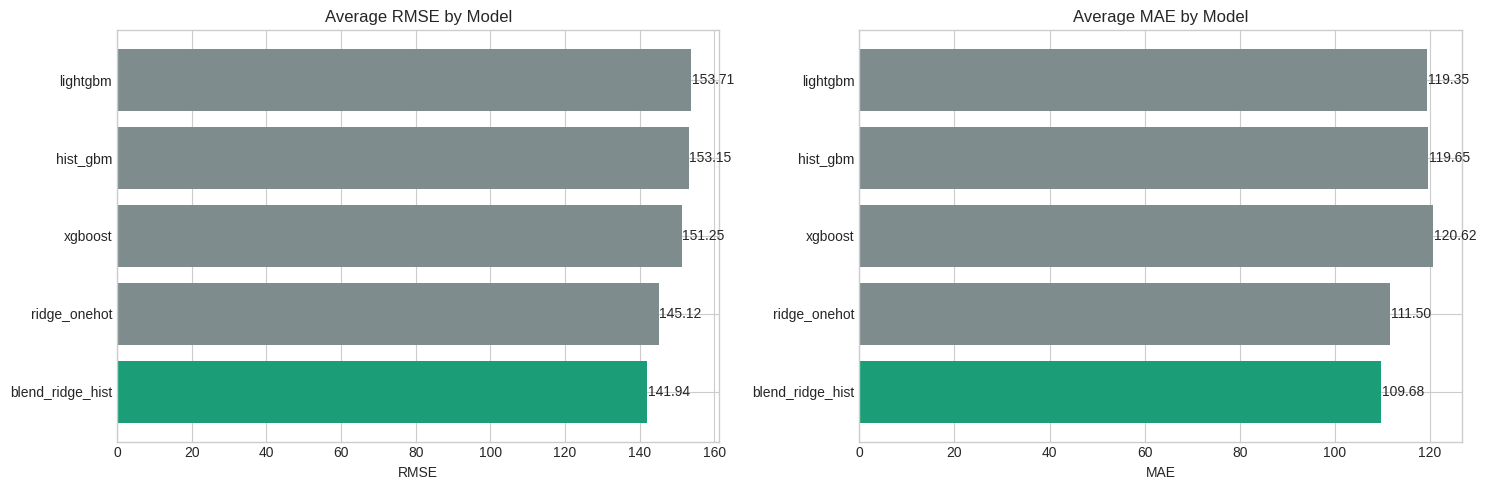

In [6]:
plot_df = candidate_summary.sort_values("avg_rmse", ascending=True).copy()
selected_model_name = plot_df.iloc[0]["model"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(plot_df["model"], plot_df["avg_rmse"], color=["#1b9e77" if m == selected_model_name else "#7f8c8d" for m in plot_df["model"]])
axes[0].set_title("Average RMSE by Model")
axes[0].set_xlabel("RMSE")
for y_pos, value in enumerate(plot_df["avg_rmse"]):
    axes[0].text(value + 0.2, y_pos, f"{value:.2f}", va="center")

axes[1].barh(plot_df["model"], plot_df["avg_mae"], color=["#1b9e77" if m == selected_model_name else "#7f8c8d" for m in plot_df["model"]])
axes[1].set_title("Average MAE by Model")
axes[1].set_xlabel("MAE")
for y_pos, value in enumerate(plot_df["avg_mae"]):
    axes[1].text(value + 0.2, y_pos, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()

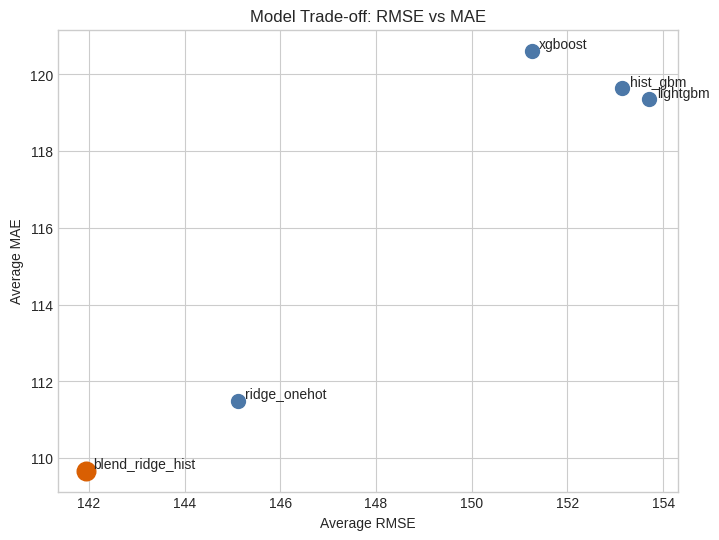

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in candidate_summary.iterrows():
    color = "#d95f02" if row["model"] == selected_model_name else "#4c78a8"
    size = 180 if row["model"] == selected_model_name else 100
    ax.scatter(row["avg_rmse"], row["avg_mae"], s=size, color=color)
    ax.text(row["avg_rmse"] + 0.15, row["avg_mae"] + 0.05, row["model"], fontsize=10)

ax.set_title("Model Trade-off: RMSE vs MAE")
ax.set_xlabel("Average RMSE")
ax.set_ylabel("Average MAE")
plt.show()

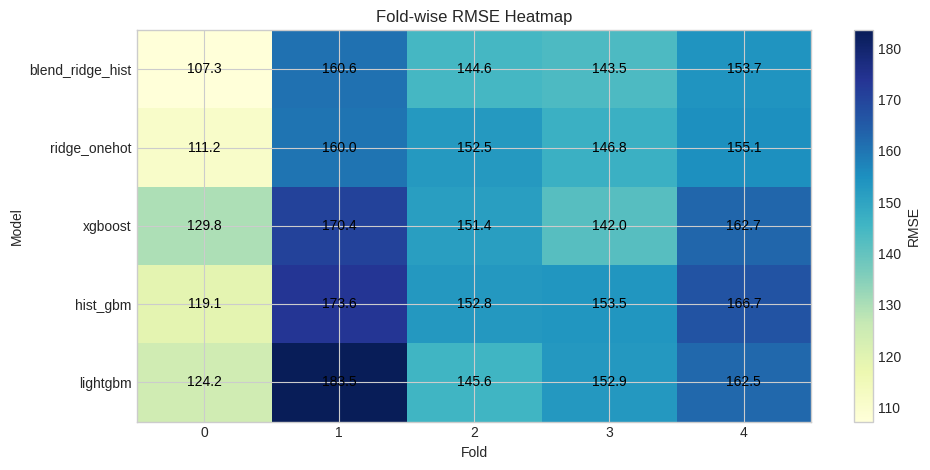

In [8]:
rmse_heatmap = candidate_folds.pivot(index="model", columns="fold", values="rmse").loc[plot_df["model"]]

fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(rmse_heatmap.values, cmap="YlGnBu", aspect="auto")
ax.set_title("Fold-wise RMSE Heatmap")
ax.set_xlabel("Fold")
ax.set_ylabel("Model")
ax.set_xticks(range(len(rmse_heatmap.columns)))
ax.set_xticklabels(rmse_heatmap.columns)
ax.set_yticks(range(len(rmse_heatmap.index)))
ax.set_yticklabels(rmse_heatmap.index)

for i in range(rmse_heatmap.shape[0]):
    for j in range(rmse_heatmap.shape[1]):
        ax.text(j, i, f"{rmse_heatmap.iloc[i, j]:.1f}", ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="RMSE")
plt.tight_layout()
plt.show()

In [9]:
baseline_best = baseline_summary.iloc[0]
final_best = candidate_summary.iloc[0]

comparison = pd.DataFrame(
    [
        {"stage": "Baseline", "model": baseline_best["model"], "rmse": baseline_best["avg_rmse"], "mae": baseline_best["avg_mae"]},
        {"stage": "Final", "model": final_best["model"], "rmse": final_best["avg_rmse"], "mae": final_best["avg_mae"]},
    ]
)
comparison

,stage,model,rmse,mae
0,Baseline,ridge_onehot,147.231708,112.061409
1,Final,blend_ridge_hist,141.935523,109.676954


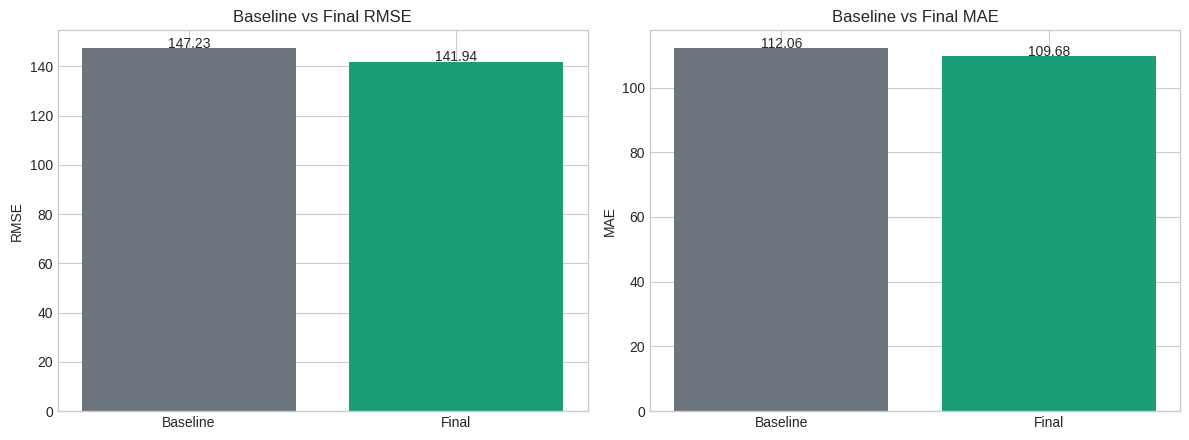

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(comparison["stage"], comparison["rmse"], color=["#6c757d", "#1b9e77"])
axes[0].set_title("Baseline vs Final RMSE")
axes[0].set_ylabel("RMSE")
for idx, value in enumerate(comparison["rmse"]):
    axes[0].text(idx, value + 0.2, f"{value:.2f}", ha="center")

axes[1].bar(comparison["stage"], comparison["mae"], color=["#6c757d", "#1b9e77"])
axes[1].set_title("Baseline vs Final MAE")
axes[1].set_ylabel("MAE")
for idx, value in enumerate(comparison["mae"]):
    axes[1].text(idx, value + 0.2, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

## 5. Final Model Architecture

In [11]:
builders = get_candidate_builders()
merged = merge_optional_features(
    train_frame,
    turn_feature_frame,
    key_columns=["game_id", "human_nickname"],
)
numeric_features, categorical_features = infer_feature_lists(
    merged,
    target_column="human_rating",
    exclude_columns=["game_id", "human_nickname", "fold"],
)
blend_model = builders["blend_ridge_hist"](numeric_features, categorical_features)

if isinstance(blend_model, WeightedBlendRegressor):
    architecture = pd.DataFrame(
        {
            "component": [name for name, _ in blend_model.estimators],
            "weight": blend_model.weights,
        }
    )
else:
    architecture = pd.DataFrame()

architecture

,component,weight
0,ridge,0.65
1,hist_gbm,0.35


`blend_ridge_hist` is a weighted ensemble with two components:

- `ridge`: a ridge regression pipeline with scaled numeric features and one-hot encoded categorical features
- `hist_gbm`: a histogram gradient boosting regressor with ordinal-encoded categorical inputs

The final prediction is:

`0.65 * ridge_prediction + 0.35 * hist_gbm_prediction`


## 6. Fit The Final Model And Generate Test Predictions

In [12]:
selected_model_name, selected_model, numeric_features, categorical_features, refreshed_summary = fit_best_candidate_model(
    train_frame,
    feature_frame=turn_feature_frame,
    key_columns=["game_id", "human_nickname"],
)

print("Selected final model:", selected_model_name)
print("Average RMSE:", round(float(refreshed_summary.iloc[0]["avg_rmse"]), 4))
print("Average MAE:", round(float(refreshed_summary.iloc[0]["avg_mae"]), 4))
print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))

Selected final model: blend_ridge_hist
Average RMSE: 141.9355
Average MAE: 109.677
Numeric feature count: 43
Categorical feature count: 7


In [13]:
test_predictions = predict_test_frame(
    selected_model,
    test_frame,
    numeric_features,
    categorical_features,
    feature_frame=turn_feature_frame,
    key_columns=["game_id", "human_nickname"],
)

test_predictions.head(10)

,game_id,nickname,predicted_rating
0,2,Super,1958.315585
1,7,Priya1,1909.720238
2,11,TileRunner,1633.836569
3,14,Anfield223,1970.078432
4,27,friesbasil,2025.619328
5,28,Eloquent,1855.244940
6,32,Super,2031.406258
7,40,eugenius,1693.200051
8,41,marvin,1685.521049
9,44,jlevedit,1692.523580


## 7. Final Summary

- The final notebook now uses metadata and turn-level aggregate features.
- The selected submission model is `blend_ridge_hist`.
- This model outperforms the metadata-only baseline under grouped-human validation.
- Final validation score: RMSE `141.9355`, MAE `109.6770`.
